In [29]:
import torch
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [31]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [32]:
print("Target names:", iris.target_names)

Target names: ['setosa' 'versicolor' 'virginica']


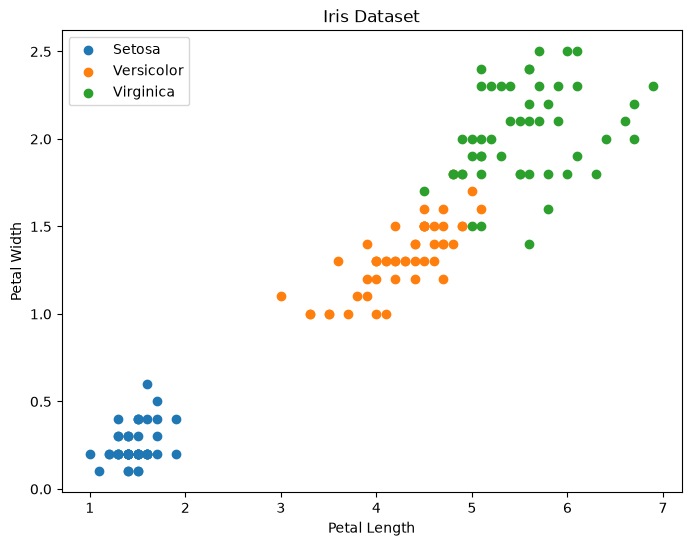

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 2],
    X[y == 0, 3],
    label="Setosa"
)

plt.scatter(
    X[y == 1, 2],
    X[y == 1, 3],
    label="Versicolor"
)

plt.scatter(
    X[y == 2, 2],
    X[y == 2, 3],
    label="Virginica"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset")
plt.legend()
plt.show()

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.fit_transform(X_test)

In [36]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)
print(X_test.shape)

torch.Size([120, 4])
torch.Size([30, 4])


In [37]:
def euclidean_distance(x1, x2):
    return torch.sqrt(torch.sum((x1 - x2) ** 2))

In [38]:
def get_neighbors(X_train, y_train, x, k):
    distances = []

    for i in range(len(X_train)):
        distance = euclidean_distance(X_train[i], x)

        distances.append((distance, y_train[i]))

    distances.sort(key=lambda item: item[0])

    neighbors = distances[:k]

    return neighbors

In [39]:
def predict_one(X_train, y_train, x, k):
    neighbors = get_neighbors(
        X_train,
        y_train,
        x,
        k
    )

    labels = torch.tensor(
        [label.item() for _, label in neighbors],
        dtype=torch.long
    )

    prediction = torch.bincount(labels).argmax()

    return prediction

In [40]:
def predict(X_train, y_train, X_test, k):
    predictions = []

    for x in X_test:
        prediction = predict_one(
            X_train,
            y_train,
            x,
            k
        )

        predictions.append(prediction)

    return torch.stack(predictions)

In [41]:
k = 5

y_pred = predict(
    X_train,
    y_train,
    X_test,
    k
)

print("Predictions:")
print(y_pred)

print("\nActual:")
print(y_test)

Predictions:
tensor([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2,
        2, 1, 1, 0, 2, 0])

Actual:
tensor([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2,
        2, 1, 1, 0, 2, 0])


In [42]:
accuracy = (y_pred == y_test).float().mean()

print(f"Accuracy: {accuracy.item():.4f}")

Accuracy: 1.0000


In [43]:
cm = confusion_matrix(
    y_test.numpy(),
    y_pred.numpy()
)

print(cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


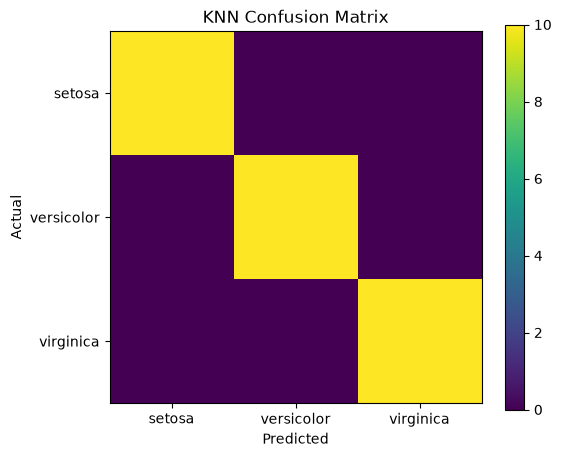

In [44]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.xticks(
    [0, 1, 2],
    iris.target_names
)

plt.yticks(
    [0, 1, 2],
    iris.target_names
)

plt.colorbar()

plt.show()

In [45]:
print(
    classification_report(
        y_test.numpy(),
        y_pred.numpy(),
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [46]:
k_values = [1, 3, 5, 7, 9, 11]

accuracies = []

for k in k_values:

    y_pred = predict(
        X_train,
        y_train,
        X_test,
        k
    )

    accuracy = (y_pred == y_test).float().mean().item()

    accuracies.append(accuracy)

    print(f"K = {k}, Accuracy = {accuracy:.4f}")

K = 1, Accuracy = 0.9667
K = 3, Accuracy = 0.9667
K = 5, Accuracy = 1.0000
K = 7, Accuracy = 1.0000
K = 9, Accuracy = 1.0000
K = 11, Accuracy = 0.9667


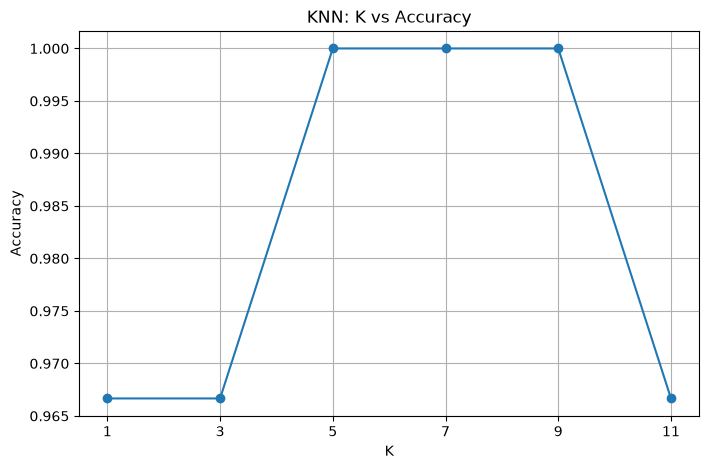

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN: K vs Accuracy")

plt.xticks(k_values)

plt.grid()

plt.show()